Trying different type of models for LST estimation

## General paths, libraries and functions

In [ ]:
!pip install seaborn
!pip install statsmodels
!pip install rasterstats

In [ ]:
import os
import numpy as np
import rasterio
from rasterio import mask
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from rasterstats import zonal_stats
import joblib


In [ ]:
# user-defined paths
base_dir = '../../../datos-notebooks/3.global-data-cba/'
census_areas_name = ''
trained_models_path = '../../../datos-notebooks/1.HR-data-bologna/1.4.LST-prediction/' # modeles trained with HR data
landsat_image = 'LC09_L2SP_229082_20240202_20240205_02_T1'


In [188]:
# inputs

# LST
lst_cropped_path = os.path.join(base_dir, f'LST/LST_cropped_celsius{landsat_image}.tif') # values out of bound are 0
lst_clipped_path = os.path.join(base_dir, f'LST/LST_clipped_celsius{landsat_image}.tif') #values out of bound are nan

# vectors
census_areas_path = os.path.join(base_dir, census_areas_name)
# variables - Best results (pearson correlation with LST) for window size -- same as used in HR data
ndwi_1_path = os.path.join(base_dir, f'land-cover-{landsat_image}/moving-windows/ndwi/Class_1_window7.tif')
ndvi_1_path = os.path.join(base_dir, f'land-cover-{landsat_image}/moving-windows/ndvi/Class_1_window7.tif')
ndvi_0p5_path = os.path.join(base_dir, f'land-cover-{landsat_image}/moving-windows/ndvi/Class_0p5_window11.tif')
veg_vol_path = os.path.join(base_dir, f'objects-height/moving-windows/tree-volume/trees_window15.tif')
veg_height_path = os.path.join(base_dir, f'objects-height/moving-windows/tree-height/trees_height_window9.tif')
built_vol_path = os.path.join(base_dir, 'objects-height/moving-windows/building-volume/buildings_window13.tif')
built_area_path = os.path.join(base_dir, 'objects-height/moving-windows/building-area/building_area_window5.tif')
building_height_path = os.path.join(base_dir, 'objects-height/moving-windows/building-height/building_height_window5.tif')
mean_elev_path = os.path.join(base_dir, 'topography/moving_windows/elev_mean/elev_mean_win111.tif')
mean_slope_path = os.path.join(base_dir, 'topography/moving_windows/slope_mean/slope_mean_win101.tif')
northness_path = os.path.join(base_dir, 'topography/moving_windows/northness/northness_win37.tif')



In [157]:
# output directorys
lst_prediction_folder = os.path.join(base_dir, 'LST-prediction/')
os.makedirs(lst_prediction_folder, exist_ok=True)
standarized_folder_path = os.path.join(lst_prediction_folder, 'standarized_variables')

## Dataset preparation

### mask rasters to city boundary

In [189]:
with rasterio.open(lst_clipped_path) as src:
    lst = src.read(1)

lst_mask = np.isnan(lst)

# mask values out of city boundary
ndwi_1 = np.where(lst_mask, np.nan, rasterio.open(ndwi_1_path).read(1).astype("float32"))
ndvi_1 = np.where(lst_mask, np.nan, rasterio.open(ndvi_1_path).read(1).astype("float32"))
ndvi_0p5 = np.where(lst_mask, np.nan, rasterio.open(ndvi_0p5_path).read(1).astype("float32"))
veg_vol = np.where(lst_mask, np.nan, rasterio.open(veg_vol_path).read(1).astype("float32"))
veg_height = np.where(lst_mask, np.nan, rasterio.open(veg_height_path).read(1).astype("float32"))
built_vol = np.where(lst_mask, np.nan, rasterio.open(built_vol_path).read(1).astype("float32"))
built_area = np.where(lst_mask, np.nan, rasterio.open(built_area_path).read(1).astype("float32"))
built_height = np.where(lst_mask, np.nan, rasterio.open(building_height_path).read(1).astype("float32"))
mean_elev = np.where(lst_mask, np.nan, rasterio.open(mean_elev_path).read(1).astype("float32"))
mean_slope = np.where(lst_mask, np.nan, rasterio.open(mean_slope_path).read(1).astype("float32"))
northness = np.where(lst_mask, np.nan, rasterio.open(northness_path).read(1).astype("float32"))

# fixing "northness" for southern hemisphere
#north = rasterio.open(northness_path).read(1).astype("float32") # Read northness raster
#northness = np.where(lst_mask, np.nan, -north) # Invert northness (north -> south)

rasters_masked = {
    "Water": ndwi_1,
    "Dense vegetation presence": ndvi_1,
    "Sparse vegetation presence": ndvi_0p5,
    "Vegetation volume": veg_vol,
    "Vegetation height": veg_height,
    "Built volume": built_vol,
    "Built area": built_area,
    "Building height": built_height,
    "Elevation": mean_elev,
    "Slope": mean_slope,
    "Northness": northness
}

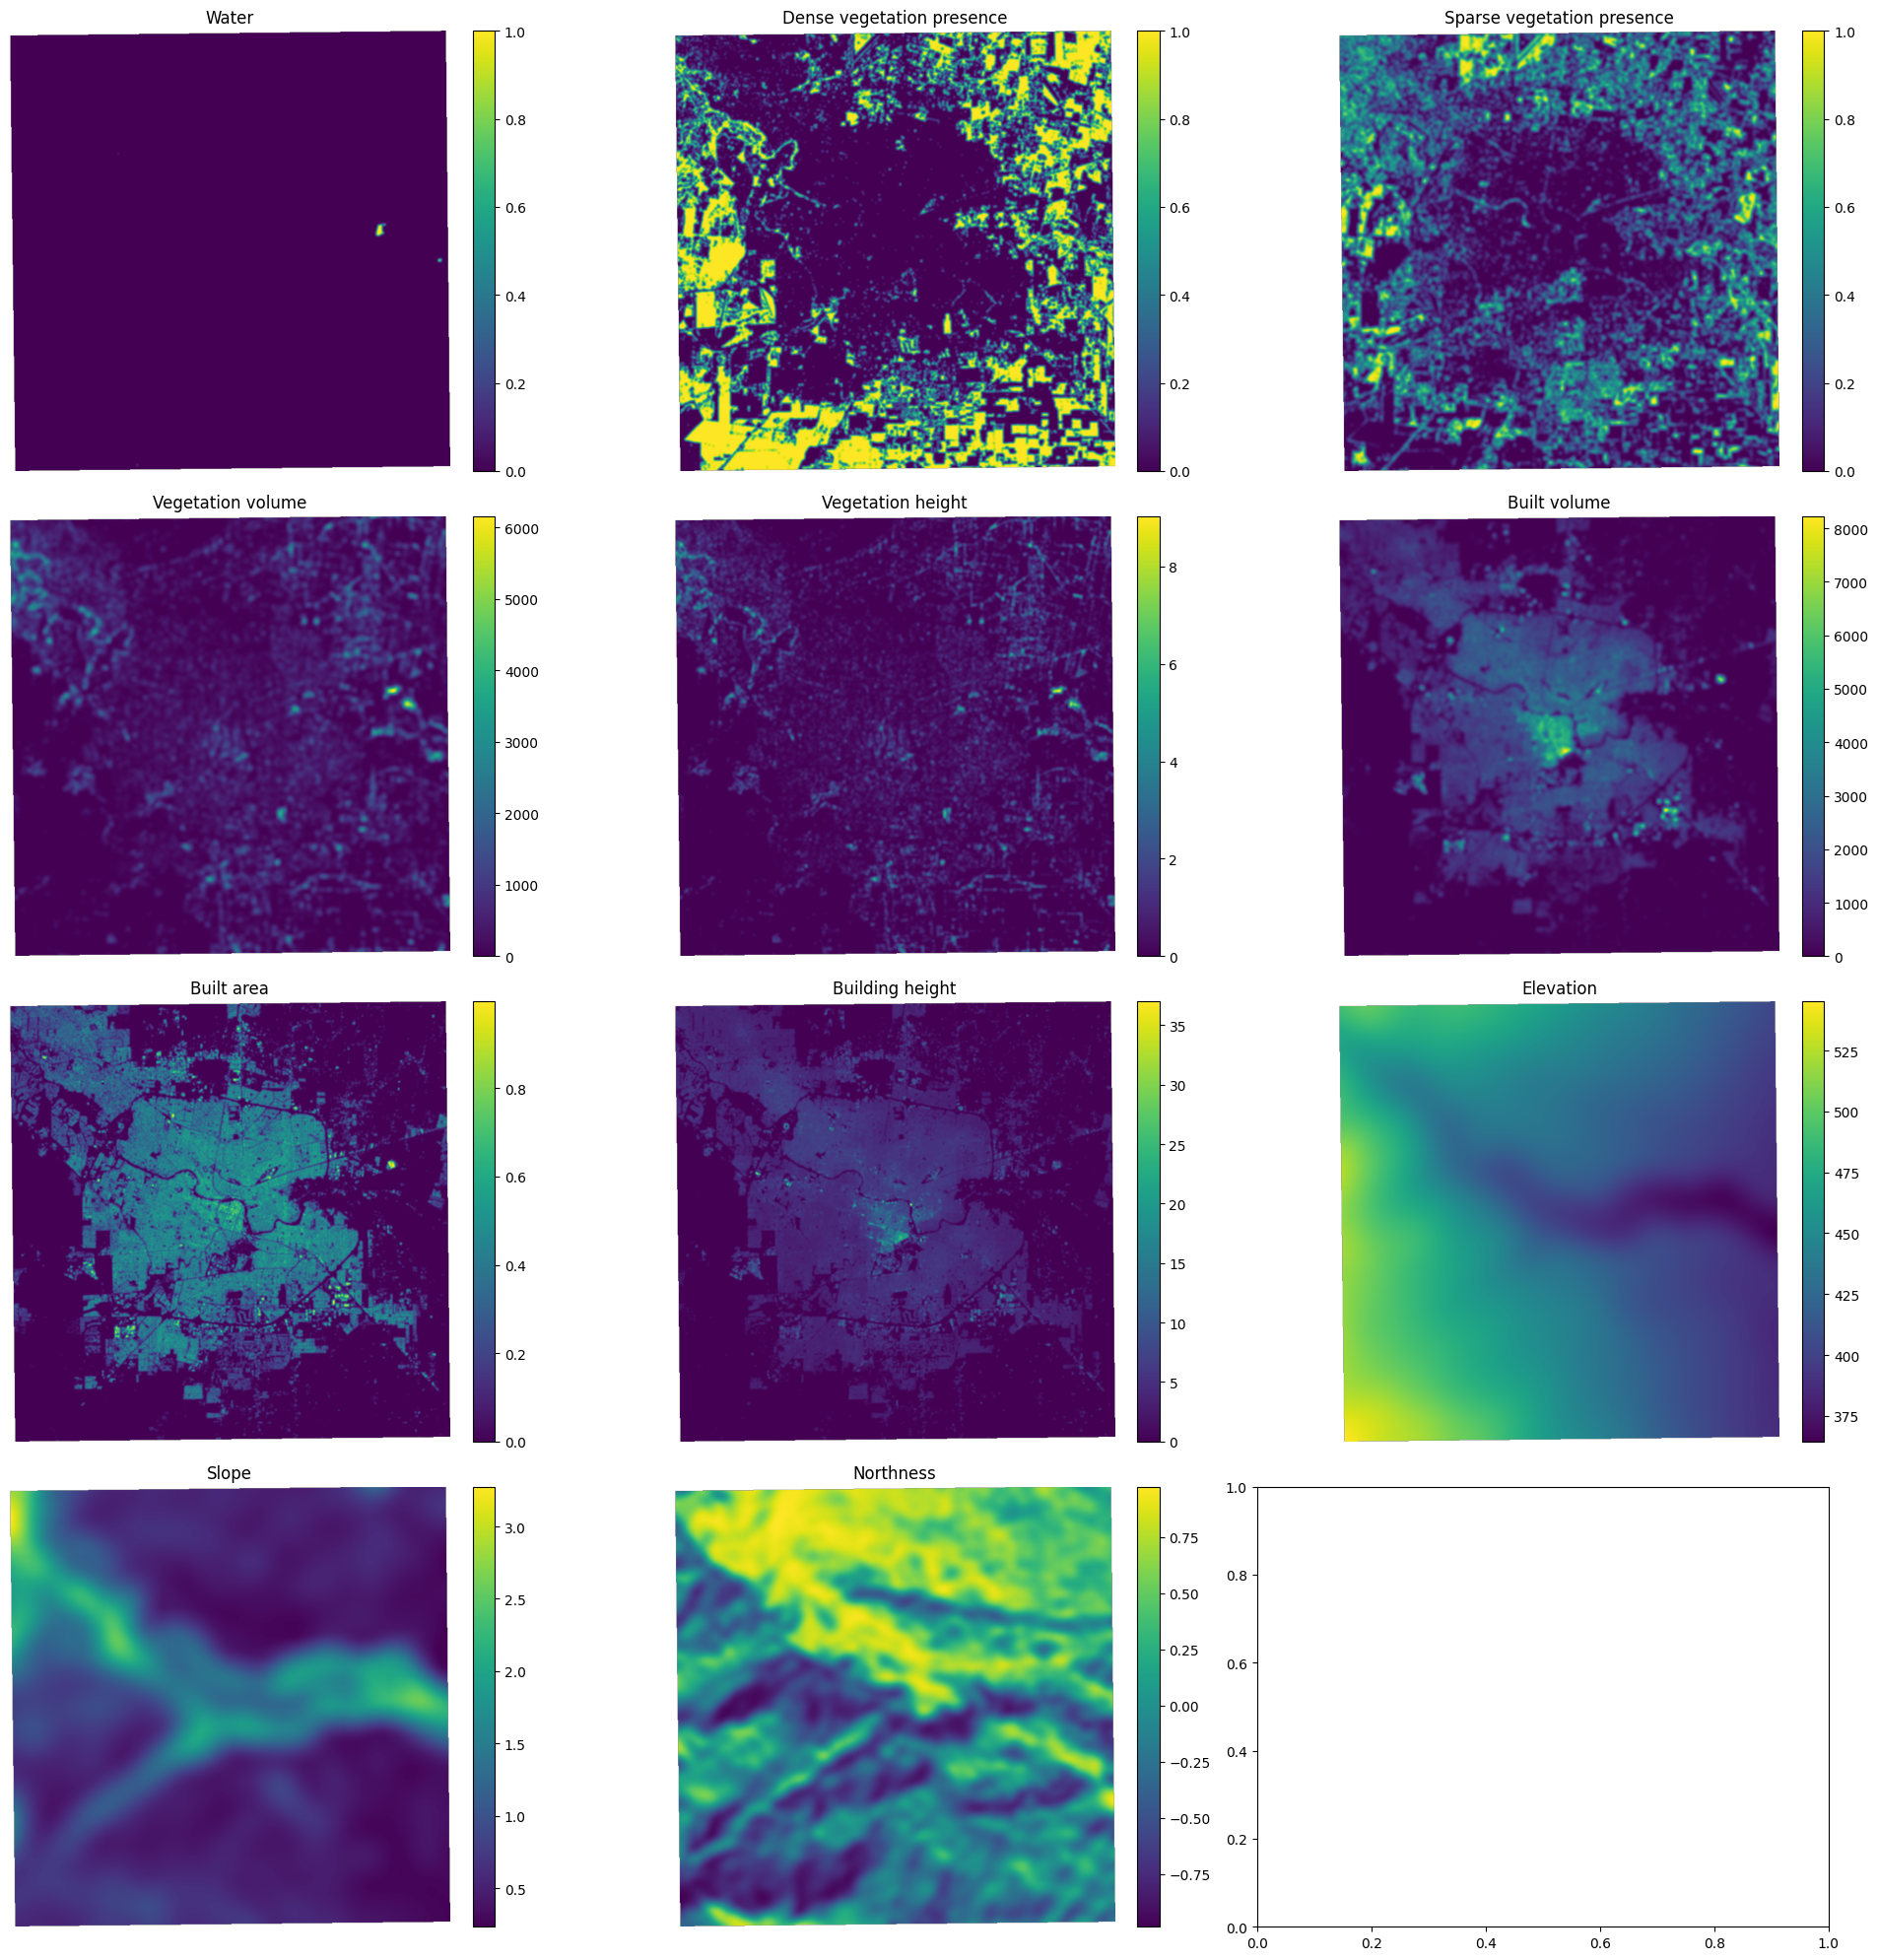

In [190]:
#plot masked rasters 

fig, axes = plt.subplots(4, 3, figsize=(20, 20))

for ax, (name, data) in zip(axes.flat, rasters_masked.items()):

    img = ax.imshow(data, cmap='viridis')
    ax.set_title(name)
    ax.axis('off')
    fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)


plt.tight_layout()
plt.show()

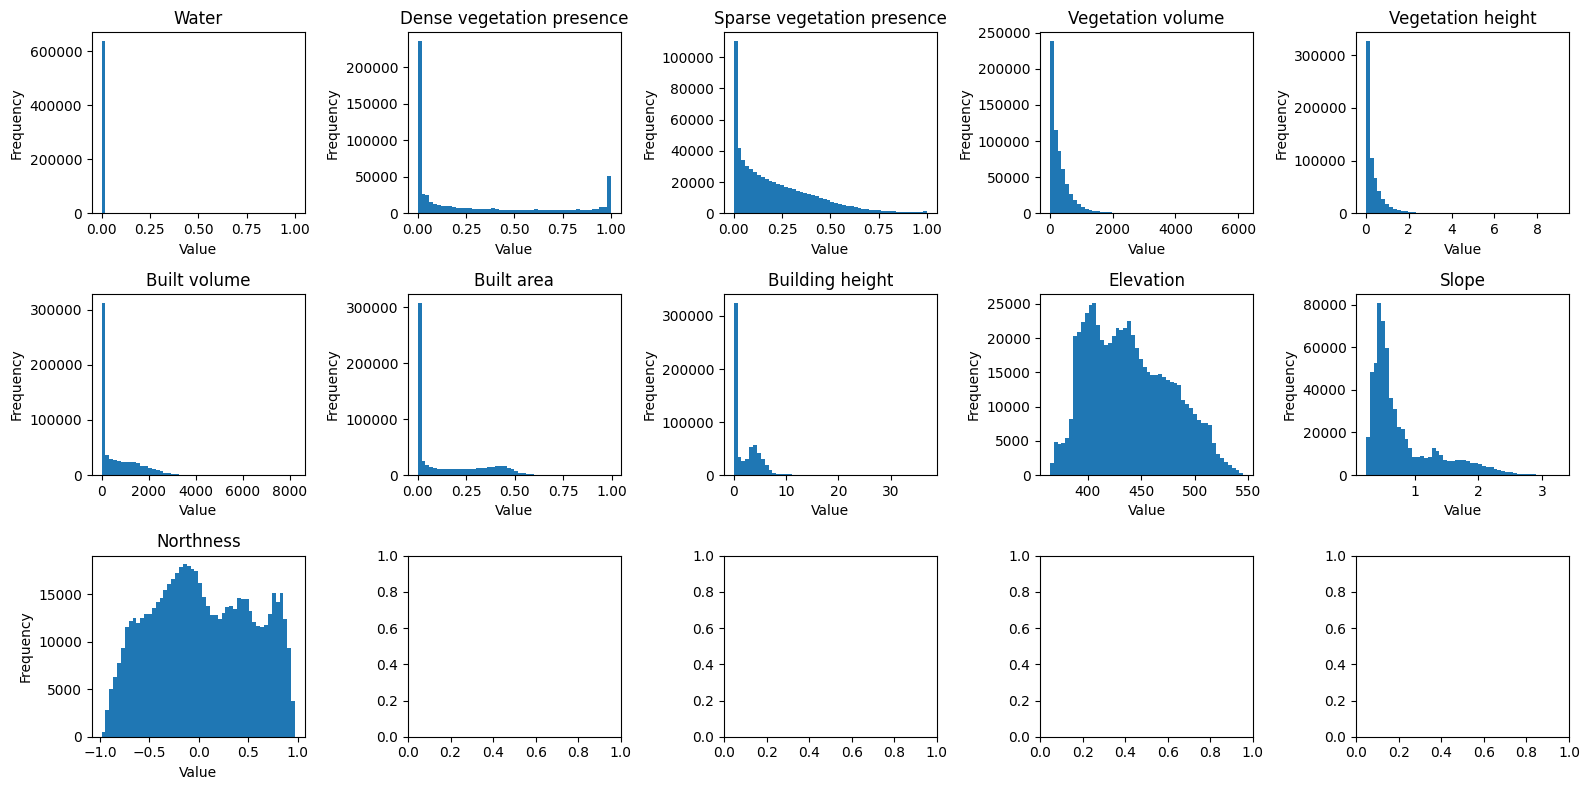

In [191]:
# Plot histograms of masked rasters
fig, axes = plt.subplots(3, 5, figsize=(16, 8))
axes = axes.flatten()  # Flatten to 1D for easy indexing

for i, (name, arr) in enumerate(rasters_masked.items()):
    # Plot histogram using already-masked arrays
    axes[i].hist(arr[~np.isnan(arr)], bins=50)
    axes[i].set_title(name)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

# Hide unused subplots (if less than 8 rasters)
for j in range(i + 1, 8):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

### standarize variables - mean:0, std:1

In [192]:
os.makedirs(standarized_folder_path, exist_ok=True)

In [193]:
# Z-score standardization for regression predictors

def standardize_array(arr, profile, out_path):
    mean = np.nanmean(arr)
    std = np.nanstd(arr)
    z = (arr - mean) / std

    profile.update(dtype='float32')

    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(z.astype('float32'), 1)

In [194]:
# Apply standarization
with rasterio.open(lst_clipped_path) as src:
    profile = src.profile.copy()
    
standardize_array(ndwi_1, profile, os.path.join(standarized_folder_path, 'NDWI_1_z.tif'))
standardize_array(ndvi_1, profile, os.path.join(standarized_folder_path, 'NDVI_1_z.tif'))
standardize_array(ndvi_0p5, profile, os.path.join(standarized_folder_path, 'NDVI_0p5_z.tif'))
standardize_array(veg_vol, profile, os.path.join(standarized_folder_path, 'VEG_VOL_z.tif'))
standardize_array(veg_height, profile, os.path.join(standarized_folder_path, 'VEG_HEIGHT_z.tif'))
standardize_array(built_vol, profile, os.path.join(standarized_folder_path, 'BUILT_VOL_z.tif'))
standardize_array(built_area, profile, os.path.join(standarized_folder_path, 'BUILT_AREA_z.tif'))
standardize_array(built_height, profile, os.path.join(standarized_folder_path, 'BUILDING_HEIGHT_z.tif'))
standardize_array(mean_elev, profile, os.path.join(standarized_folder_path, 'ELEV_z.tif'))
standardize_array(mean_slope, profile, os.path.join(standarized_folder_path, 'SLOPE_z.tif'))
standardize_array(northness, profile, os.path.join(standarized_folder_path, 'NORTH_z.tif'))

In [222]:
std_rasters_paths = {
    #"Agua": os.path.join(standarized_folder_path, "NDWI_1_z.tif"),
    "Vegetación densa": os.path.join(standarized_folder_path, "NDVI_1_z.tif"),
    "Vegetación dispersa": os.path.join(standarized_folder_path, "NDVI_0p5_z.tif"),
    "Altura de vegetación": os.path.join(standarized_folder_path, "VEG_HEIGHT_z.tif"),
    #"Volumen de vegetación": os.path.join(standarized_folder_path, "VEG_VOL_z.tif"),
    #"Volumen construido": os.path.join(standarized_folder_path, "BUILT_VOL_z.tif"),  # Excluido para evitar duplicación de información
    "Área construida": os.path.join(standarized_folder_path, "BUILT_AREA_z.tif"),
    "Altura de edificación": os.path.join(standarized_folder_path, "BUILDING_HEIGHT_z.tif"),
    #"Elevación": os.path.join(standarized_folder_path, "ELEV_z.tif"),
    "Pendiente": os.path.join(standarized_folder_path, "SLOPE_z.tif"),
    "Orientación norte": os.path.join(standarized_folder_path, "NORTH_z.tif")
}

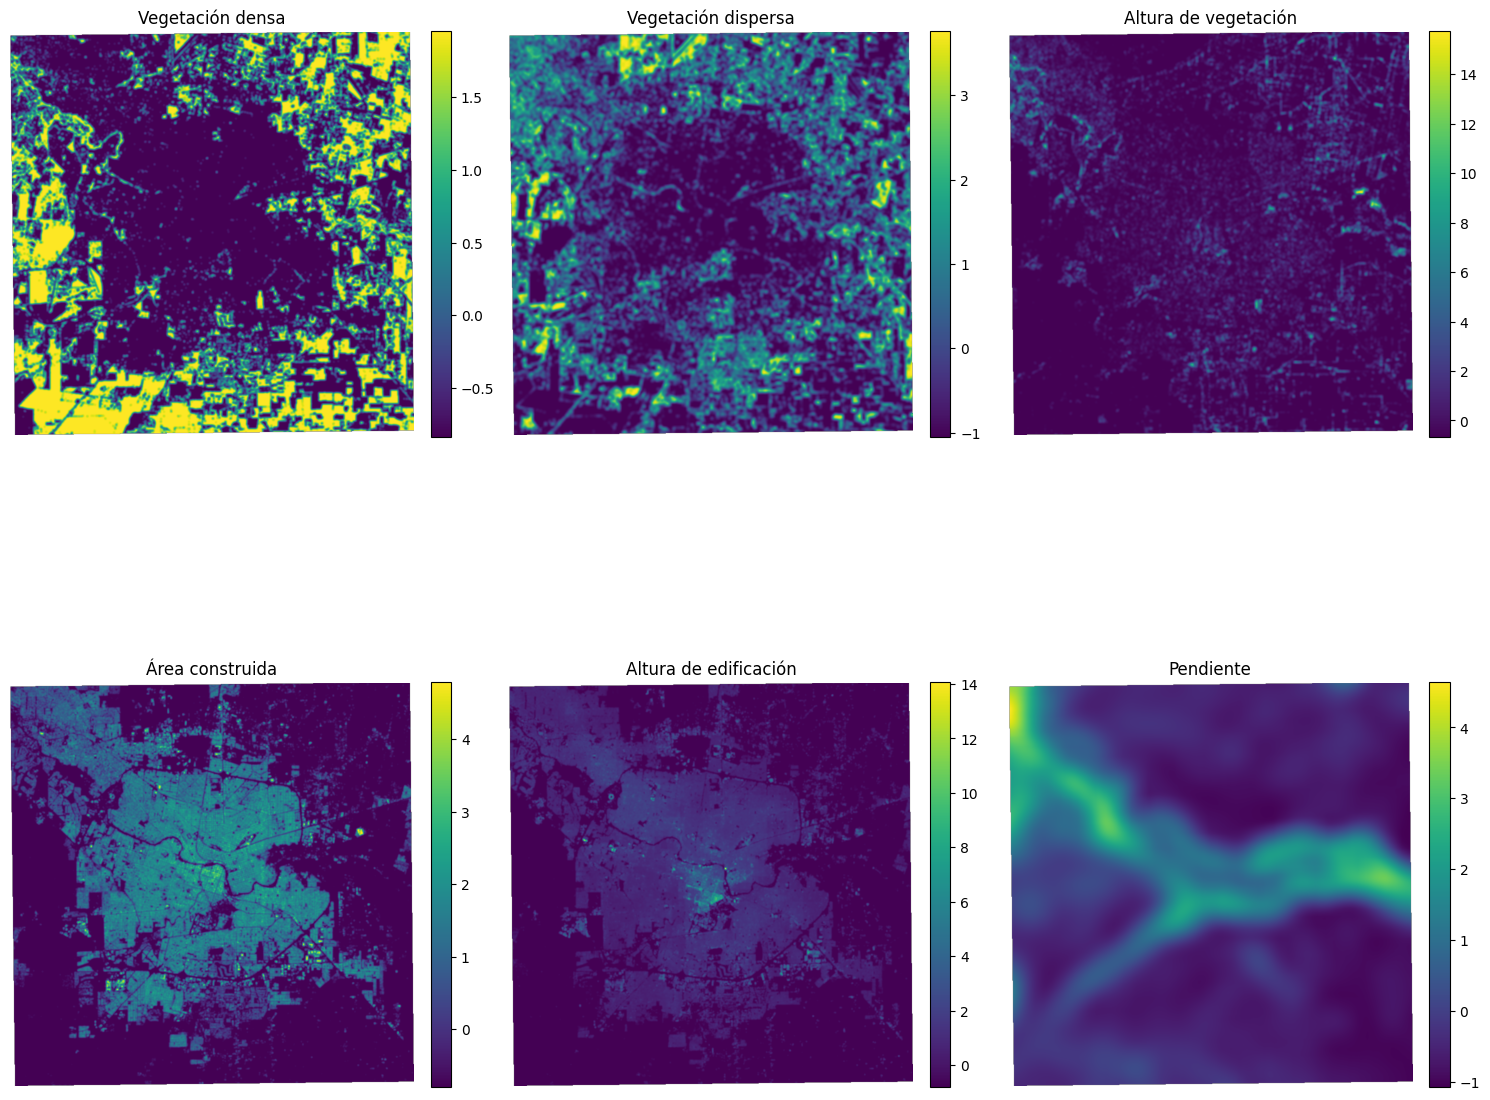

In [223]:
#plot cropped and standardized rasters

fig, axes = plt.subplots(2, 3, figsize=(15, 15))

for ax, (name, path) in zip(axes.flat, std_rasters_paths.items()):
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)

    img = ax.imshow(data, cmap='viridis')
    ax.set_title(name)
    ax.axis('off')
    fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)


plt.tight_layout()
plt.show()

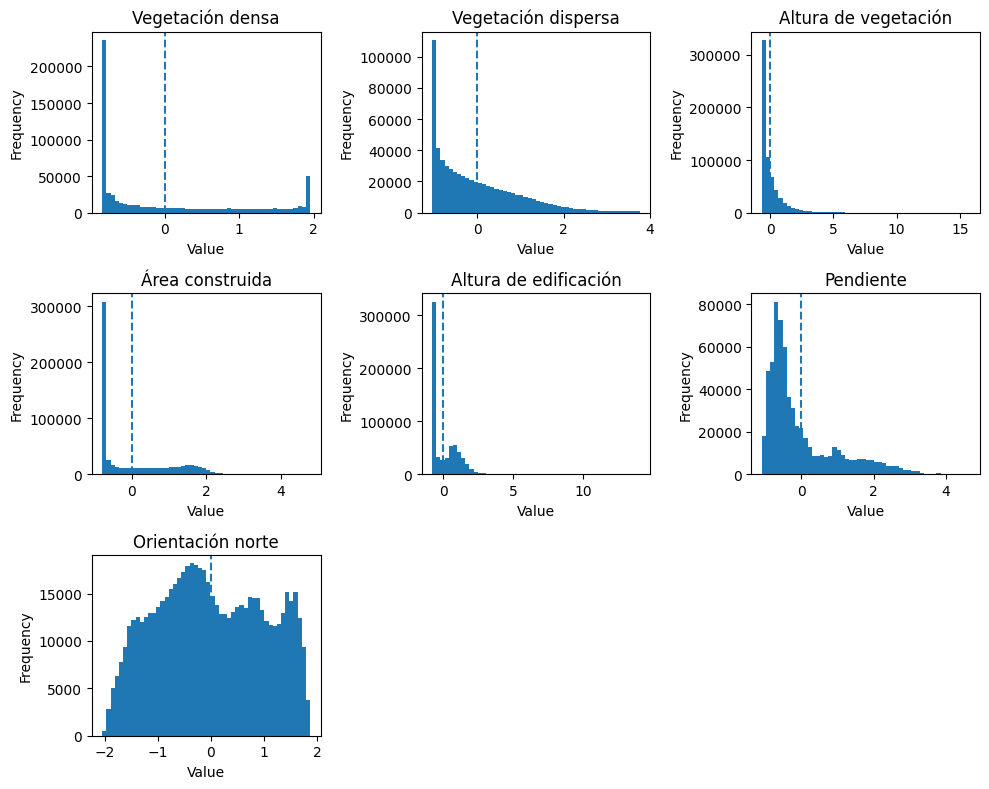

In [246]:

fig, axes = plt.subplots(3, 3, figsize=(10, 8))
axes = axes.flatten()  # Flatten to 1D for easy indexing

for i, (name, path) in enumerate(std_rasters_paths.items()):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nodata = src.nodata

    # Plot histogram
    axes[i].hist(arr[~np.isnan(arr)], bins=50)
    axes[i].set_title(name)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")
    axes[i].axvline(0, linestyle='--')
    
    axes[-1].set_visible(False)
    axes[-2].set_visible(False)
    

plt.tight_layout()
plt.show()

### stratified sampling of LST

In [248]:
rasters = {"LST": lst_clipped_path} # create dictionary with LST raster (not standardized)
rasters.update(std_rasters_paths) # add standardized rasters to the dictionary
#rasters.pop("Variable name", None) # to delete one variable if needed


In [249]:
rasters

{'LST': '../../../datos-notebooks/3.global-data-cba/LST/LST_clipped_celsiusLC09_L2SP_229082_20240202_20240205_02_T1.tif',
 'Vegetación densa': '../../../datos-notebooks/3.global-data-cba/LST-prediction/standarized_variables\\NDVI_1_z.tif',
 'Vegetación dispersa': '../../../datos-notebooks/3.global-data-cba/LST-prediction/standarized_variables\\NDVI_0p5_z.tif',
 'Altura de vegetación': '../../../datos-notebooks/3.global-data-cba/LST-prediction/standarized_variables\\VEG_HEIGHT_z.tif',
 'Área construida': '../../../datos-notebooks/3.global-data-cba/LST-prediction/standarized_variables\\BUILT_AREA_z.tif',
 'Altura de edificación': '../../../datos-notebooks/3.global-data-cba/LST-prediction/standarized_variables\\BUILDING_HEIGHT_z.tif',
 'Pendiente': '../../../datos-notebooks/3.global-data-cba/LST-prediction/standarized_variables\\SLOPE_z.tif',
 'Orientación norte': '../../../datos-notebooks/3.global-data-cba/LST-prediction/standarized_variables\\NORTH_z.tif'}

In [250]:
# Create bins
n_bins = 10

# Read and flatten
data_arrays = {}
for name, path in rasters.items():
    with rasterio.open(path) as src:
        arr = src.read(1)
        data_arrays[name] = arr.flatten()

df = pd.DataFrame(data_arrays)

df = df.dropna() # Drop rows with NaN

df['LST_bin'] = pd.qcut(df['LST'], n_bins, labels=False) # Create LST bins for stratification 

In [251]:
# Stratified sampling: 10% of each bin

sample_fraction = 0.1
df_sampled = df.groupby('LST_bin', group_keys=False).apply(
    lambda x: x.sample(frac=sample_fraction, random_state=42)
)

# Drop bin column
df_sampled = df_sampled.drop(columns=['LST_bin']).reset_index(drop=True)

print(df_sampled.head())


         LST  Vegetación densa  Vegetación dispersa  Altura de vegetación  \
0  37.638557          1.381562            -0.370135             -0.632612   
1  33.502754         -0.835101            -0.708604             -0.528636   
2  37.655647          1.954004            -0.934898              5.988946   
3  37.412968          1.015052             0.572994              3.672063   
4  37.553108          1.945634            -1.006678              5.464715   

   Área construida  Altura de edificación  Pendiente  Orientación norte  
0        -0.799312              -0.811669  -0.239261          -1.646785  
1         1.331424               0.762839   0.427630           0.528500  
2        -0.799312              -0.811669  -0.440347           0.631521  
3        -0.373156               0.908553  -0.538659          -0.781650  
4        -0.799312              -0.811669   0.047736          -0.568979  


C:\Users\guada\AppData\Local\Temp\ipykernel_10756\4163941717.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby('LST_bin', group_keys=False).apply(


In [252]:
# Show min, max and count of LST values in each bin

df_sampled['LST_bin'] = pd.qcut(df_sampled['LST'], n_bins, labels=False) # Recreate bins for the sampled dataset

for b in range(n_bins):
    values_in_bin = df_sampled[df_sampled['LST_bin'] == b]['LST']
    print(f"Bin {b}: min = {values_in_bin.min():.2f}, max = {values_in_bin.max():.2f}, count = {len(values_in_bin)}")

df_sampled = df_sampled.drop(columns=['LST_bin'])

Bin 0: min = 24.89, max = 37.93, count = 6398
Bin 1: min = 37.93, max = 38.93, count = 6396
Bin 2: min = 38.93, max = 39.48, count = 6401
Bin 3: min = 39.49, max = 39.93, count = 6425
Bin 4: min = 39.93, max = 40.36, count = 6366
Bin 5: min = 40.37, max = 40.85, count = 6418
Bin 6: min = 40.86, max = 41.47, count = 6392
Bin 7: min = 41.47, max = 42.30, count = 6387
Bin 8: min = 42.30, max = 43.57, count = 6378
Bin 9: min = 43.57, max = 52.85, count = 6394


### Descriptive statistics

In [253]:
# Split features and target
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']

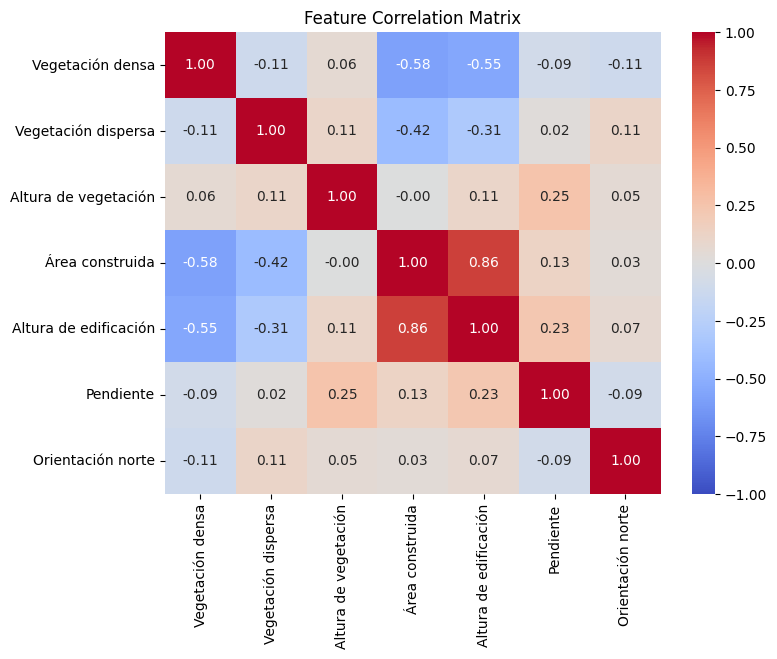

In [254]:
# Compute correlation matrix (only features)
corr_matrix = X.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.show()


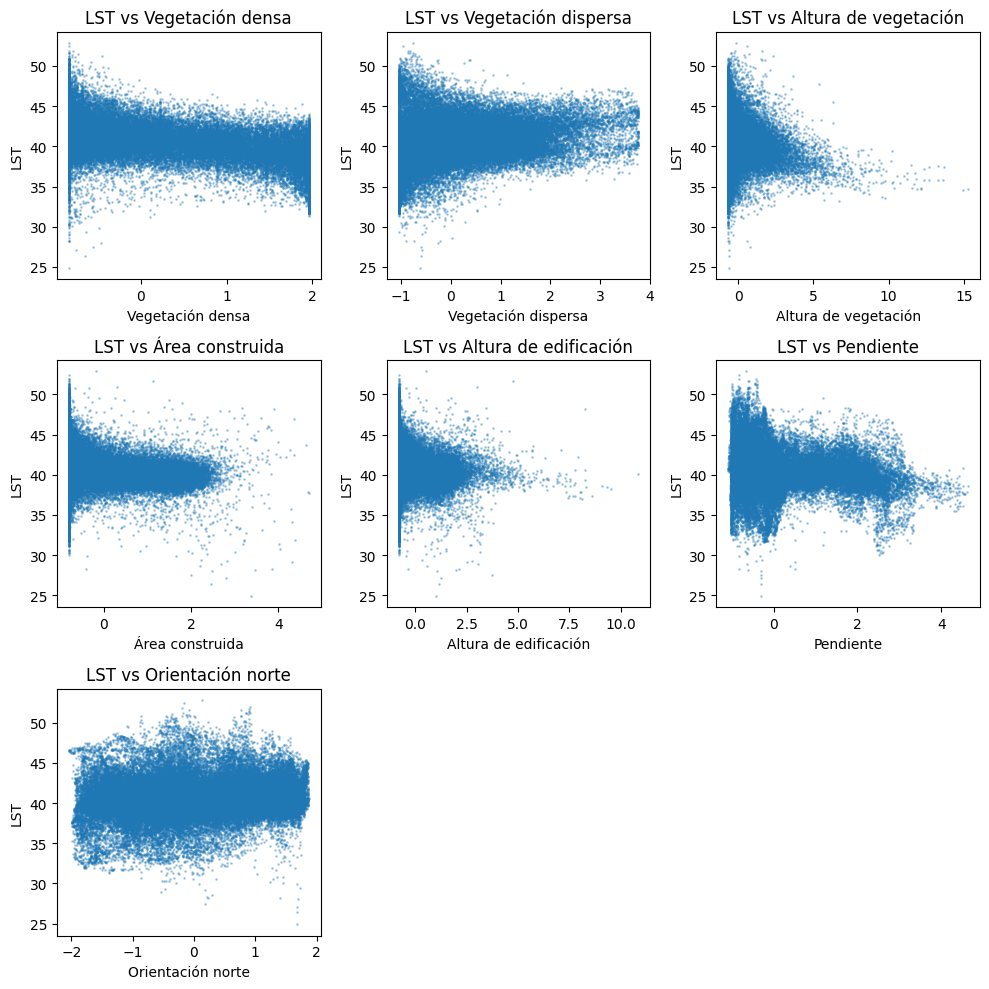

In [272]:
# Plot correlations: Variables vs LST

n_vars = len(X)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten() 

for i, v in enumerate(X.columns):
    axes[i].scatter(X[v], y, s=1, alpha=0.3)
    axes[i].set_xlabel(v)
    axes[i].set_ylabel("LST")
    axes[i].set_title(f"LST vs {v}")
    
    axes[-1].set_visible(False)
    axes[-2].set_visible(False)

plt.tight_layout()
plt.show()

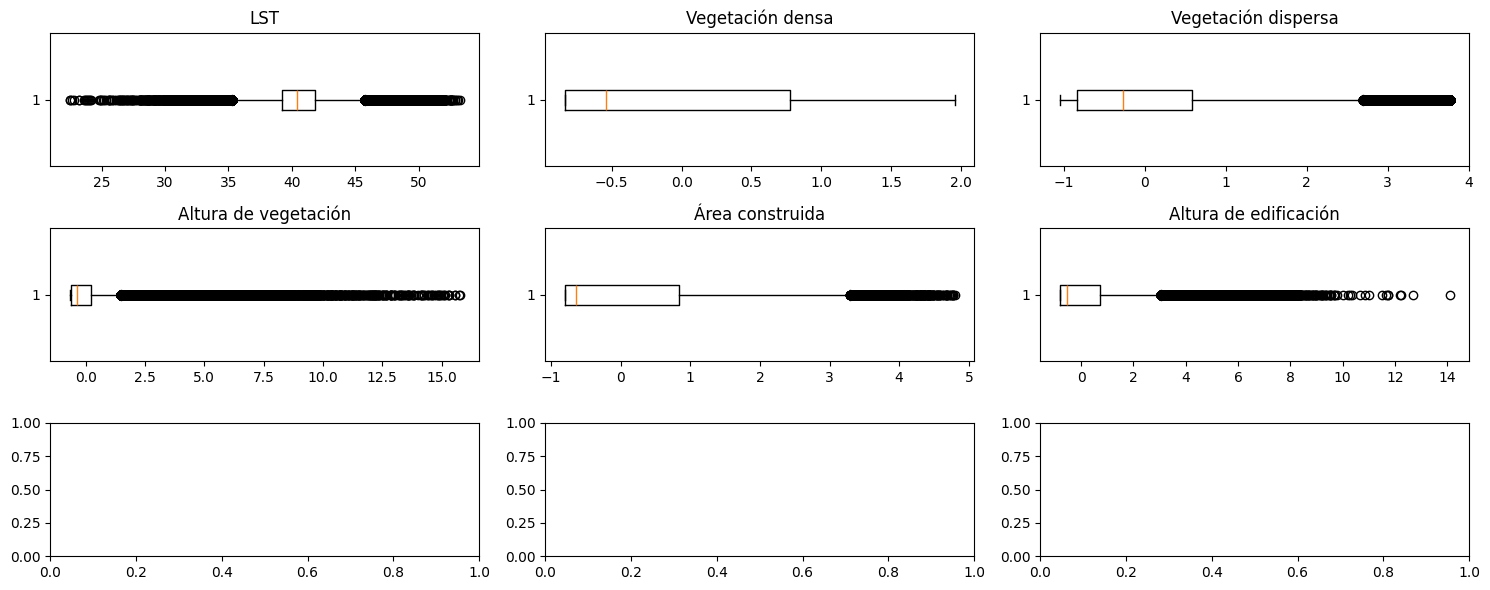

In [256]:
fig, axes = plt.subplots(3, 3, figsize=(15, 6))
axes = axes.flatten()

for i, v in enumerate(df.columns[:6]):
    axes[i].boxplot(df[v], vert=False)
    axes[i].set_title(v)

for ax in axes[len(df.columns):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


In [257]:
df_sampled

,LST,Vegetación densa,Vegetación dispersa,Altura de vegetación,Área construida,Altura de edificación,Pendiente,Orientación norte
0,37.638557,1.381562,-0.370135,-0.632612,-0.799312,-0.811669,-0.239261,-1.646785
1,33.502754,-0.835101,-0.708604,-0.528636,1.331424,0.762839,0.427630,0.528500
2,37.655647,1.954004,-0.934898,5.988946,-0.799312,-0.811669,-0.440347,0.631521
3,37.412968,1.015052,0.572994,3.672063,-0.373156,0.908553,-0.538659,-0.781650
4,37.553108,1.945634,-1.006678,5.464715,-0.799312,-0.811669,0.047736,-0.568979
...,...,...,...,...,...,...,...,...
63950,46.385273,-0.835101,-0.710527,0.134484,-0.799312,-0.811669,-0.920143,0.370019
63951,44.037090,-0.835101,-0.940104,-0.269547,2.210417,3.601940,-0.616751,0.081159
63952,46.344257,-0.835101,-1.047767,-0.659116,-0.799312,-0.811669,-0.213174,-2.001970
63953,46.993679,-0.835101,-1.047767,-0.659116,-0.799312,-0.811669,-0.272332,-1.407283


In [258]:
y = df_sampled["LST"].values
X = df_sampled.drop(columns=["LST"])

In [259]:
X

,Vegetación densa,Vegetación dispersa,Altura de vegetación,Área construida,Altura de edificación,Pendiente,Orientación norte
0,1.381562,-0.370135,-0.632612,-0.799312,-0.811669,-0.239261,-1.646785
1,-0.835101,-0.708604,-0.528636,1.331424,0.762839,0.427630,0.528500
2,1.954004,-0.934898,5.988946,-0.799312,-0.811669,-0.440347,0.631521
3,1.015052,0.572994,3.672063,-0.373156,0.908553,-0.538659,-0.781650
4,1.945634,-1.006678,5.464715,-0.799312,-0.811669,0.047736,-0.568979
...,...,...,...,...,...,...,...
63950,-0.835101,-0.710527,0.134484,-0.799312,-0.811669,-0.920143,0.370019
63951,-0.835101,-0.940104,-0.269547,2.210417,3.601940,-0.616751,0.081159
63952,-0.835101,-1.047767,-0.659116,-0.799312,-0.811669,-0.213174,-2.001970
63953,-0.835101,-1.047767,-0.659116,-0.799312,-0.811669,-0.272332,-1.407283


## Training model

### Random Forest

In [260]:
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=500,       # number of trees
    max_depth=None,         # no max depth
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)


,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [261]:
y_pred = rf_model.predict(X_test)

# Métricas
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")



MAE:  0.9196
MSE:  1.7300
RMSE: 1.3153
R²:   0.7109


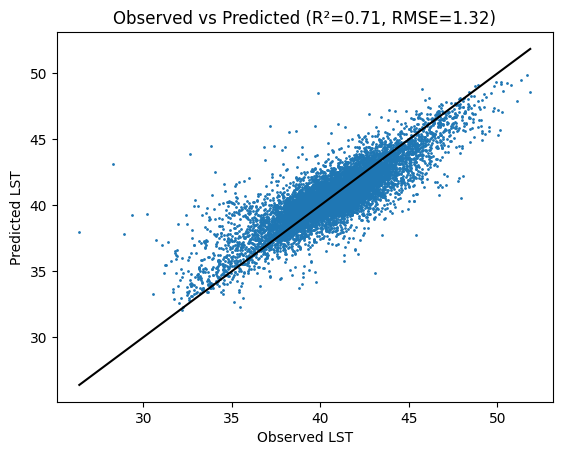

In [262]:
# Gráfico
plt.figure()
plt.scatter(y_test, y_pred, s=1)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color="black")
plt.xlabel("Observed LST")
plt.ylabel("Predicted LST")
plt.title(f"Observed vs Predicted (R²={r2:.2f}, RMSE={rmse:.2f})")
plt.show()

In [263]:
# Error metrics -- checking with train data 
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.3f}") 
# it means 97% of variance is explained by the model in the training data -- from which 15% is overfitting (0.97-0.82=0.15)
print(f"RMSE: {rmse:.3f}")


R²: 0.711
RMSE: 1.315


In [264]:
# Variable importance
importances = rf_model.feature_importances_

# Create dataframe for sorting
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
})

# Sort by importance (descending)
importance_df = importance_df.sort_values(by="importance", ascending=False)

# Print ordered results
for _, row in importance_df.iterrows():
    print(f"{row['feature']}: {row['importance']:.3f}")

Vegetación densa: 0.317
Pendiente: 0.156
Vegetación dispersa: 0.126
Área construida: 0.125
Orientación norte: 0.110
Altura de edificación: 0.104
Altura de vegetación: 0.063


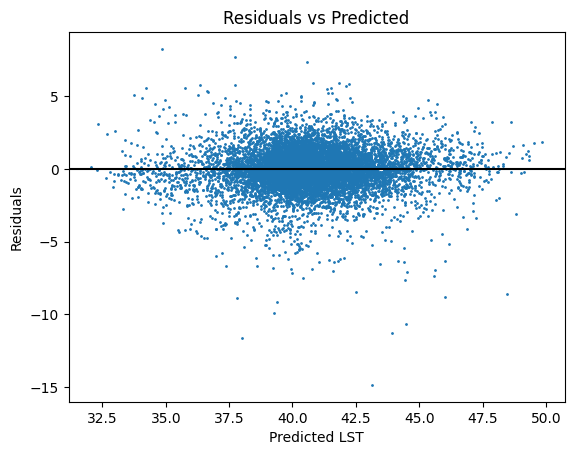

In [265]:
# Residuals plot
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals, s=1)
plt.axhline(0, color='black')
plt.xlabel("Predicted LST")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

## Applying RF model in all the city

In [266]:
print(X.columns.tolist())


['Vegetación densa', 'Vegetación dispersa', 'Altura de vegetación', 'Área construida', 'Altura de edificación', 'Pendiente', 'Orientación norte']


In [268]:
# Predictor order (MUST match training)
predictor_order = ['Vegetación densa', 'Vegetación dispersa', 'Altura de vegetación', 'Área construida', 'Altura de edificación', 'Pendiente', 'Orientación norte']


# Read rasters using 'rasters' dict
arrays = []
meta = None

for name in predictor_order:
    path = rasters[name]   # get path from existing dict
    with rasterio.open(path) as src:
        arr = src.read(1)
        arrays.append(arr)
        if meta is None:
            meta = src.meta.copy()

stack = np.stack(arrays, axis=-1)  # (rows, cols, n_features)


# Mask nodata pixels
nodata_mask = np.any(np.isnan(stack), axis=-1)


# Reshape for model prediction
nrows, ncols, nbands = stack.shape
X_map = stack.reshape(-1, nbands)

valid = ~nodata_mask.ravel()
X_valid = X_map[valid]

# Predict LST
y_map = np.full(X_map.shape[0], np.nan)   # allocate output
y_map[valid] = rf_model.predict(X_valid) # calls the trained model

# Back to raster shape
lst_pred = y_map.reshape(nrows, ncols)

# Save raster
meta.update(dtype="float32", count=1, nodata=np.nan)

out_path = os.path.join(lst_prediction_folder, "LST_predicted_RF.tif")

with rasterio.open(out_path, "w", **meta) as dst:
    dst.write(lst_pred.astype("float32"), 1)
    

C:\Users\guada\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


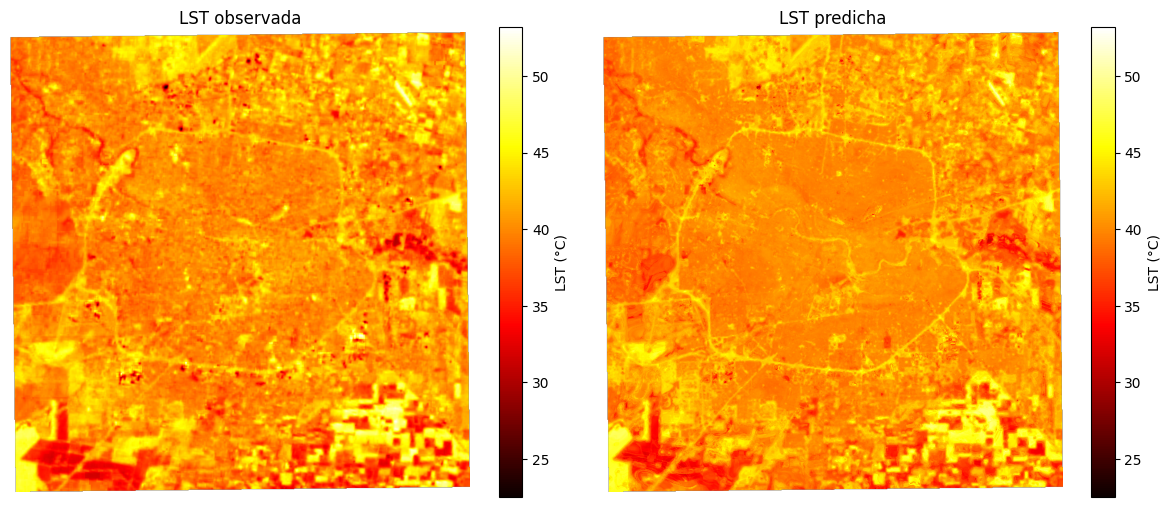

In [270]:
# Plot observed vs predicted LST

lst_predicted_path = os.path.join(lst_prediction_folder, "LST_predicted_RF.tif")

with rasterio.open(lst_clipped_path) as src:
    lst_observed = src.read(1)

with rasterio.open(lst_predicted_path) as src:
    lst_pred = src.read(1)
    
vmin = np.nanmin(lst_observed)
vmax = np.nanmax(lst_observed)

# Plot 
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(lst_observed, vmin=vmin, vmax=vmax, cmap="hot")  
plt.colorbar(label="LST (°C)")
plt.title("LST observada")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(lst_pred, vmin=vmin, vmax=vmax, cmap="hot")  
plt.colorbar(label="LST (°C)")
plt.title("LST predicha")
plt.axis("off")

plt.tight_layout()
plt.show()
